# Level 1 — Classic CNNs (VGG-16, ResNet-18 / 50)

**목표**: VGG 와 ResNet 을 직접 구현하여 Set A 위에서 Multi-task 로 학습하고, **Skip Connection** 이 깊은 네트워크의 수렴에 미치는 영향을 분석합니다.

**금지 사항**: `torchvision.models.*`, `timm`. 단, 위 라이브러리의 코드를 *참고하여 직접 타이핑* 하는 것은 허용됩니다.

본 노트북의 산출물:
1. 학습된 체크포인트 (`checkpoints/level1_*.pth`).
2. VGG-16, ResNet-18, ResNet-50 의 `Avg-Macro-F1` 및 속성별 Macro-F1 표.
3. VGG (skip 없음) vs ResNet (skip 있음) 의 학습 손실 곡선 비교.

In [2]:
import os
import sys

# # 1. 코랩 환경에서 레포지토리가 클론되지 않은 경우에만 Clone 진행
# repo_name = "2026-HYU-AUE8088-PA2"
# if not os.path.exists(f"/content/{repo_name}"):
#     !git clone https://github.com/IRCVLab/2026-HYU-AUE8088-PA2.git

# # 2. 작업 디렉토리를 레포지토리의 최상단(Root)으로 변경
# %cd /content/{repo_name}

# 프로젝트 루트를 sys.path에 추가 (src 모듈 인식용)
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# 의존성 설치 (이미 설치된 패키지는 빠르게 skip)
!pip install -q -r ../requirements.txt

import torch
from torch.utils.data import DataLoader

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.utils.metrics import collect_predictions, confusion_matrices, CLASS_NAMES
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES
from src.models.resnet import resnet18, resnet50
from src.models.vgg import VGG16

SEED = 42
set_seed(SEED, deterministic=True)   # 재현성을 위한 시드 고정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


### Weights & Biases 설정

학습 곡선과 속성별 Macro-F1 을 자동으로 로깅합니다. 사용하지 않으려면 `WANDB_PROJECT = None` 으로 두세요 — 로깅 호출은 자동으로 no-op 이 됩니다.

최초 1회만:
```python
import wandb; wandb.login()   # API key 입력
```

In [5]:
import wandb; wandb.login()   # API key 입력

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jisang/.netrc.
wandb: Currently logged in as: journeyofbabo (journeyofbabo-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
WANDB_PROJECT = "aue8088-pa2"   # 비활성화하려면 None
WANDB_TAGS    = ["level1"]
# 환경변수로도 끌 수 있음:  os.environ["WANDB_DISABLED"] = "true"

In [7]:
DATA_ROOT = "../data/set_a"
BATCH = 64

# --- 데이터셋 자동 다운로드 (Google Drive) ---------------------------------
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")
# --------------------------------------------------------------------------

# Set A 의 train/val 로더 구성
train_ds = BDDAttrDataset(DATA_ROOT, split="train", transform=train_transform())
val_ds   = BDDAttrDataset(DATA_ROOT, split="val",   transform=eval_transform())

g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, worker_init_fn=seed_worker, generator=g, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# 속성별 클래스 분포 출력 — 불균형 정도를 직접 확인할 것
for a in ATTRIBUTES:
    print(f"{a:10s} 클래스별 샘플 수 (train) = {train_ds.class_counts(a).tolist()}")

데이터셋이 이미 존재합니다 → ../data/set_a
weather    클래스별 샘플 수 (train) = [3100, 800, 400, 200, 0, 500]
scene      클래스별 샘플 수 (train) = [3052, 1386, 562]
timeofday  클래스별 샘플 수 (train) = [2479, 2129, 392]


In [ ]:
from torch import nn

def train_one(model_fn, name, epochs=20):
    """단일 모델을 학습하고 체크포인트와 wandb 산출물을 저장한다."""
    set_seed(SEED, deterministic=True)
    model = model_fn().to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    losses = {a: nn.CrossEntropyLoss() for a in ATTRIBUTES}
    cfg = TrainConfig(epochs=epochs)

    # wandb 로거 — WANDB_PROJECT 가 None 이거나 wandb 미설치 시 자동 no-op
    logger = WandbLogger(
        project=WANDB_PROJECT,
        run_name=f"level1-{name}",
        config={
            "backbone": name, "epochs": epochs, "batch": BATCH,
            "lr": 3e-4, "weight_decay": 5e-4, "seed": SEED,
            "loss_weights": cfg.loss_weights,
        },
        tags=WANDB_TAGS + [name],
    )

    trainer = MultiTaskTrainer(model, optim, sched, losses, device, cfg, logger=logger)
    history = trainer.fit(train_loader, val_loader)

    # 학습 종료 후 — 속성별 정규화 confusion matrix 를 wandb 에 업로드
    val_pred, _, val_tgt, _ = collect_predictions(model, val_loader, device)
    cms = confusion_matrices(val_pred, val_tgt)
    for a in ATTRIBUTES:
        logger.log_confusion_matrix(f"final/cm_{a}", cms[a], CLASS_NAMES[a])
    logger.finish()

    os.makedirs("../checkpoints", exist_ok=True)
    torch.save({"state_dict": model.state_dict(), "history": history},
               f"../checkpoints/level1_{name}.pth")
    return model, history

# TODO: 각 모델을 학습하고 최종 Avg-Macro-F1 및 속성별 MF1 을 기록하세요.
# vgg_model, vgg_hist = train_one(VGG16,    "vgg16",    epochs=30)
# r18_model, r18_hist = train_one(resnet18, "resnet18", epochs=30)
r50_model, r50_hist = train_one(resnet50, "resnet50", epochs=30)

[epoch 01/30] train_loss=2.4587  val_avg_MF1=0.4442  per={'weather': 0.22134164562920222, 'scene': 0.3892956721430784, 'timeofday': 0.7218955623541246}


[epoch 02/30] train_loss=2.0897  val_avg_MF1=0.4103  per={'weather': 0.22224300520930088, 'scene': 0.324487895716946, 'timeofday': 0.6840682852635044}


[epoch 03/30] train_loss=1.9507  val_avg_MF1=0.3955  per={'weather': 0.2249125959398128, 'scene': 0.32961169612053304, 'timeofday': 0.6318701705824011}


[epoch 04/30] train_loss=1.8837  val_avg_MF1=0.4898  per={'weather': 0.28671764372698955, 'scene': 0.42290541745715166, 'timeofday': 0.7597649833981771}


[epoch 05/30] train_loss=1.8531  val_avg_MF1=0.4243  per={'weather': 0.27745431372604623, 'scene': 0.42464825701382125, 'timeofday': 0.5707400909814161}


...

[epoch 29/30] train_loss=1.0815  val_avg_MF1=0.6245  per={'weather': 0.5025981543339699, 'scene': 0.5666557576102526, 'timeofday': 0.8042493718125994}


[epoch 30/30] train_loss=1.0727  val_avg_MF1=0.6172  per={'weather': 0.5014858890982973, 'scene': 0.5667773187407891, 'timeofday': 0.783211036528205}


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train/loss,█▆▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val/avg_macro_f1,▂▁▁▄▂▄▃▄▄▆▅▄▅▅▄▅▅█▆▆▇▇█▇█▇▇██▇
val/mf1_scene,▃▁▁▃▃▄▂▄▃▃▃▁▄▄▂▃▄▇▅▅▅▅▇▅█▇▇▇▇▇
val/mf1_timeofday,▅▄▃▆▁▆▅▅▇▇█▆▆▆▆▇███▆█▇█▇▇▇▇▇▇▇
val/mf1_weather,▁▁▁▃▂▄▄▄▃█▅▅▅▆▅▆▅▇▇▇▆▇▇██▇████
epoch,30
lr,0
train/loss,1.07267
val/avg_macro_f1,0.61716


: 

## 분석 (리포트 필수 포함 항목)

1. **수렴 비교**: VGG-16 과 ResNet-18 의 학습 손실 곡선을 함께 그리세요. Skip connection 이 없는 깊은 네트워크가 정체되는 현상이 관찰되는지, 그 원인은 무엇인지 서술하세요.
2. **속성별 MF1 표**: 각 백본에 대해 Weather / Scene / Time of Day 의 Macro-F1 을 표로 정리하세요. 어느 속성이 가장 어려운지, 깊이 변화에 따라 그 양상이 어떻게 바뀌는지 분석하세요.
3. **Loss 가중치 민감도**: ResNet-18 에 대해 최소 두 가지 비자명한 가중치 설정 (예: `(1, 1, 1)` vs `(2, 1, 1)`) 으로 재학습하고 Avg-MF1 변화를 보고하세요.

wandb 를 활성화한 경우 같은 프로젝트의 Run 들을 비교하면 학습 곡선·속성별 MF1·confusion matrix 가 한눈에 정리됩니다.

Available checkpoints: ['vgg16', 'resnet18', 'resnet50']


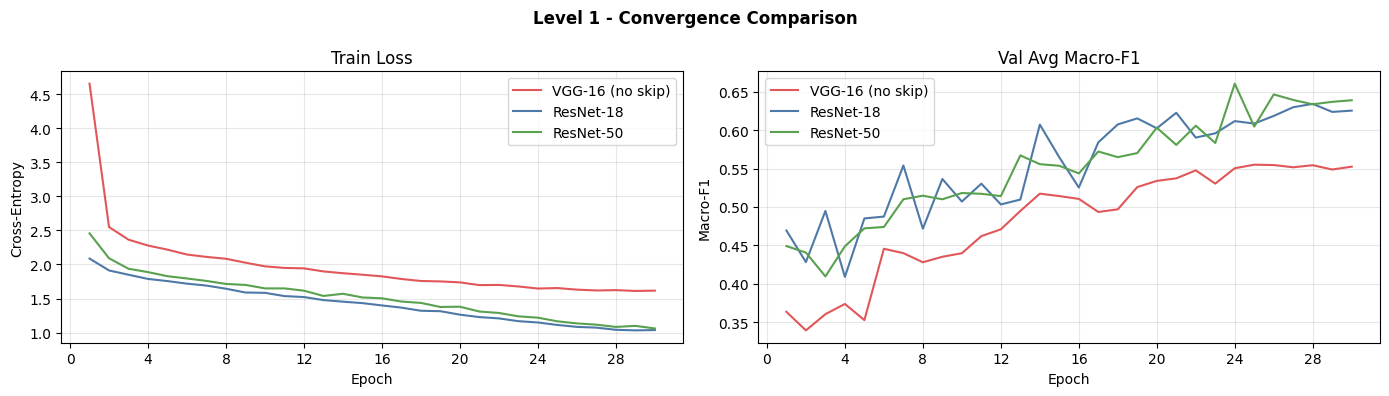

,Avg-MF1,Weather,Scene,TimeOfDay,Best Epoch
Backbone,,,,,
VGG-16 (no skip),0.5551,0.3819,0.4589,0.8244,25
ResNet-18,0.6343,0.5276,0.5681,0.8071,28
ResNet-50,0.6606,0.5501,0.6136,0.8180,24


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np

def _load_hist(name):
    path = f"../checkpoints/level1_{name}.pth"
    if not os.path.exists(path):
        return None
    return torch.load(path, map_location="cpu", weights_only=False)["history"]

_hist = {
    "vgg16":    locals().get("vgg_hist")  or _load_hist("vgg16"),
    "resnet18": locals().get("r18_hist")  or _load_hist("resnet18"),
    "resnet50": locals().get("r50_hist")  or _load_hist("resnet50"),
}
available = {k: v for k, v in _hist.items() if v is not None}
print("Available checkpoints:", list(available.keys()))

COLORS = {"vgg16": "#e15759", "resnet18": "#4e79a7", "resnet50": "#59a14f"}
LABELS = {"vgg16": "VGG-16 (no skip)", "resnet18": "ResNet-18", "resnet50": "ResNet-50"}

# 1. Convergence comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, hist in available.items():
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"],  color=COLORS[name], label=LABELS[name])
    axes[1].plot(ep, hist["val_avg_mf1"], color=COLORS[name], label=LABELS[name])
for ax, title, ylabel in zip(axes, ["Train Loss", "Val Avg Macro-F1"], ["Cross-Entropy", "Macro-F1"]):
    ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
    ax.legend(); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.suptitle("Level 1 - Convergence Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig("../checkpoints/level1_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Per-attribute MF1 table
rows = []
for name, hist in available.items():
    best = int(np.argmax(hist["val_avg_mf1"]))
    per  = hist["val_per_mf1"][best]
    rows.append({"Backbone": LABELS[name], "Avg-MF1": round(hist["val_avg_mf1"][best], 4),
                 "Weather": round(per["weather"], 4), "Scene": round(per["scene"], 4),
                 "TimeOfDay": round(per["timeofday"], 4), "Best Epoch": best + 1})
display(pd.DataFrame(rows).set_index("Backbone"))


[epoch 01/30] train_loss=2.0916  val_avg_MF1=0.4814  per={'weather': 0.2711319448021658, 'scene': 0.404728603388307, 'timeofday': 0.7682412221490379}


[epoch 02/30] train_loss=1.8929  val_avg_MF1=0.4385  per={'weather': 0.21168086833029012, 'scene': 0.38568692216038486, 'timeofday': 0.7180210104774637}


[epoch 03/30] train_loss=1.8549  val_avg_MF1=0.5165  per={'weather': 0.3071491711186953, 'scene': 0.44390028444727125, 'timeofday': 0.7985567904003789}


[epoch 04/30] train_loss=1.7934  val_avg_MF1=0.4872  per={'weather': 0.2948511016390836, 'scene': 0.3787745879851143, 'timeofday': 0.7879919644625527}


[epoch 05/30] train_loss=1.7452  val_avg_MF1=0.4823  per={'weather': 0.2686054686054686, 'scene': 0.37500484947237744, 'timeofday': 0.8031693949115416}


...

[epoch 29/30] train_loss=1.2425  val_avg_MF1=0.6272  per={'weather': 0.5139166743474086, 'scene': 0.5995433847081141, 'timeofday': 0.7681866845899744}


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


[epoch 30/30] train_loss=1.2090  val_avg_MF1=0.6231  per={'weather': 0.5080216716888937, 'scene': 0.5958588407100992, 'timeofday': 0.7655270655270655}


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
train/loss,█▆▆▆▆▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
val/avg_macro_f1,▃▂▁▃▃▅▄▆▂▄▄▆▆▆▄▅▆▆▇▇▇▇▇▇██████
val/mf1_scene,▃▁▂▃▂▅▄▆▁▂▃▄▅▆▃▅▅▄▇▆▅▅█▇██▇██▇
val/mf1_timeofday,▅▄▁▅▄█▆▇▃▇▇▇▇▇▄██▅▇▇▆▇▆▇▆▇▆▆▆▆
val/mf1_weather,▃▃▁▂▄▃▃▅▃▄▃▆▆▆▆▄▇█▇▇██▇▇▇▇████
epoch,30
lr,0
train/loss,1.209
val/avg_macro_f1,0.62314


,Avg-MF1,Weather,Scene,TimeOfDay,Best Epoch
Weights (W/S/T),,,,,
"(1, 1, 1)",0.6588,0.5410,0.6191,0.8163,27
"(2, 1, 1)",0.6564,0.5333,0.5988,0.8369,28
"(1, 3, 1)",0.6470,0.5042,0.6116,0.8253,30
"(1, 1, 2)",0.6404,0.5261,0.6165,0.7785,28


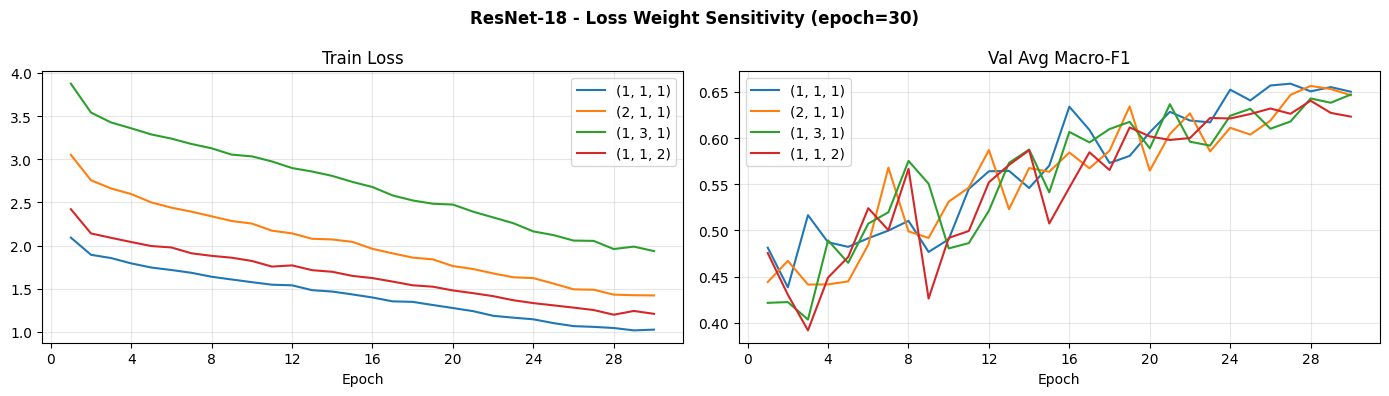

In [15]:
from torch import nn

# Loss weight sensitivity (ResNet-18)
# Format: (weather_w, scene_w, timeofday_w)
weight_configs = [
    (1, 1, 1),
    (2, 1, 1),
    (1, 3, 1),
    (1, 1, 2),
]
EPOCHS = 30  # 여기서 epoch 수 변경

def train_one_weighted(weights, epochs=EPOCHS):
    tag = "w" + "_".join(str(w) for w in weights) + f"_e{epochs}"
    set_seed(SEED, deterministic=True)
    model = resnet18().to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    cfg   = TrainConfig(epochs=epochs, loss_weights=dict(zip(ATTRIBUTES, weights)))
    logger = WandbLogger(project=WANDB_PROJECT, run_name=f"level1-r18-{tag}",
                         config={"backbone": "resnet18", "epochs": epochs, "loss_weights": cfg.loss_weights},
                         tags=WANDB_TAGS + ["weight-sensitivity"])
    history = MultiTaskTrainer(model, optim, sched,
                               {a: nn.CrossEntropyLoss() for a in ATTRIBUTES},
                               device, cfg, logger=logger).fit(train_loader, val_loader)
    logger.finish()
    torch.save({"state_dict": model.state_dict(), "history": history},
               f"../checkpoints/level1_r18_{tag}.pth")
    return history

weight_results = {}
for wc in weight_configs:
    tag  = "w" + "_".join(str(w) for w in wc) + f"_e{EPOCHS}"
    ckpt = f"../checkpoints/level1_r18_{tag}.pth"
    weight_results[wc] = (torch.load(ckpt, map_location="cpu", weights_only=False)["history"]
                          if os.path.exists(ckpt) else train_one_weighted(wc))

# Table
rows = []
for wc, hist in weight_results.items():
    best = int(np.argmax(hist["val_avg_mf1"]))
    per  = hist["val_per_mf1"][best]
    rows.append({"Weights (W/S/T)": str(wc), "Avg-MF1": round(hist["val_avg_mf1"][best], 4),
                 "Weather": round(per["weather"], 4), "Scene": round(per["scene"], 4),
                 "TimeOfDay": round(per["timeofday"], 4), "Best Epoch": best + 1})
display(pd.DataFrame(rows).set_index("Weights (W/S/T)"))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for wc, hist in weight_results.items():
    ep = range(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"],  label=str(wc))
    axes[1].plot(ep, hist["val_avg_mf1"], label=str(wc))
for ax, title in zip(axes, ["Train Loss", "Val Avg Macro-F1"]):
    ax.set(title=title, xlabel="Epoch"); ax.legend(); ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.suptitle(f"ResNet-18 - Loss Weight Sensitivity (epoch={EPOCHS})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"../checkpoints/level1_weight_sensitivity_e{EPOCHS}.png", dpi=150, bbox_inches="tight")
plt.show()
